In [3]:
import pandas as pd
from google.colab import files
uploaded= files.upload()
df = pd.read_csv("house_price_prediction.csv")


Saving house_price_prediction.csv to house_price_prediction (1).csv


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# setting the seaborn style
sns.set_style("whitegrid")

print(df.head())

   House_ID  Property_Code  Area_Sqft  Bedrooms  Bathrooms  Age_Years  \
0         1  HP-2018-10000     2548.0         1          1        5.0   
1         2  HP-2019-10001     2103.0         2          1        2.0   
2         3  HP-2020-10002     2653.0         3          2        3.0   
3         4  HP-2021-10003     3266.0         4          3        3.0   
4         5  HP-2022-10004     2036.0         2          1       16.0   

   Location Furnishing_Status      Property_Type  Parking_Spaces  \
0     Urban    Semi-Furnished             Studio               3   
1  Suburban    Semi-Furnished          Apartment               1   
2     Urban    Semi-Furnished          Apartment               2   
3  Suburban    Semi-Furnished              Villa               1   
4     Urban    Semi-Furnished  Independent House               1   

   Garden_Available  Distance_To_City_Center_Km     Price  
0                 0                         3.6  428225.0  
1                 0             

In [5]:
# basic information
print(df.shape)
print(df.info())
print(df.describe())

(7045, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   House_ID                    7045 non-null   int64  
 1   Property_Code               7045 non-null   object 
 2   Area_Sqft                   6835 non-null   float64
 3   Bedrooms                    7045 non-null   int64  
 4   Bathrooms                   7045 non-null   int64  
 5   Age_Years                   6835 non-null   float64
 6   Location                    7045 non-null   object 
 7   Furnishing_Status           6835 non-null   object 
 8   Property_Type               7045 non-null   object 
 9   Parking_Spaces              7045 non-null   int64  
 10  Garden_Available            7045 non-null   int64  
 11  Distance_To_City_Center_Km  6833 non-null   float64
 12  Price                       7045 non-null   float64
dtypes: float64(4), int64(5

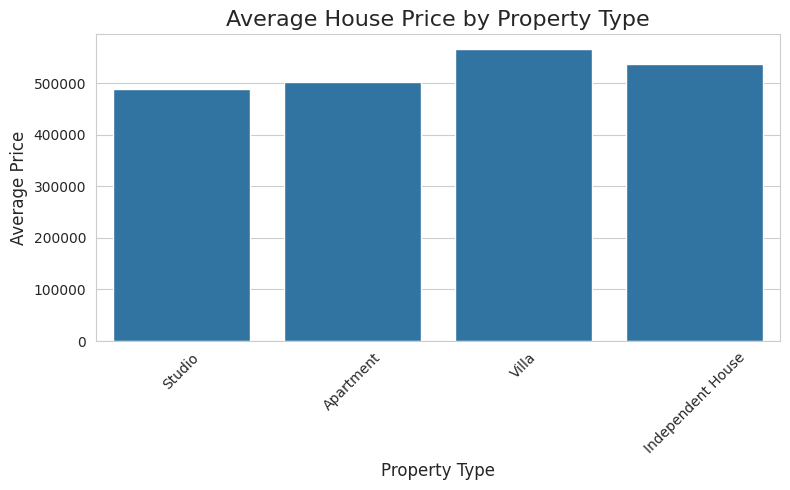

In [6]:
# barchart
# BAR CHART
# Average Price by Property Type

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x='Property_Type',
    y='Price',
    estimator='mean',
    errorbar=None
)

plt.title('Average House Price by Property Type', fontsize=16)
plt.xlabel('Property Type', fontsize=12)
plt.ylabel('Average Price', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig('bar_chart.png', dpi=300, bbox_inches='tight')

plt.show()

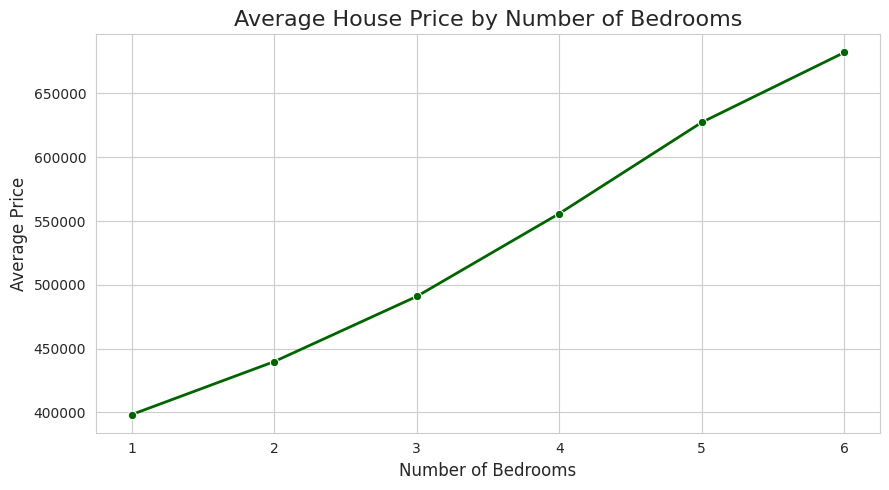

In [7]:
#linechart

bedroom_price = df.groupby('Bedrooms')['Price'].mean().reset_index()

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=bedroom_price,
    x='Bedrooms',
    y='Price',
    marker='o',
    linewidth=2,
    color='darkgreen'
)

plt.title('Average House Price by Number of Bedrooms', fontsize=16)
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Average Price', fontsize=12)

plt.xticks(bedroom_price['Bedrooms'])

plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()

plt.savefig('line_chart.png', dpi=300, bbox_inches='tight')

plt.show()

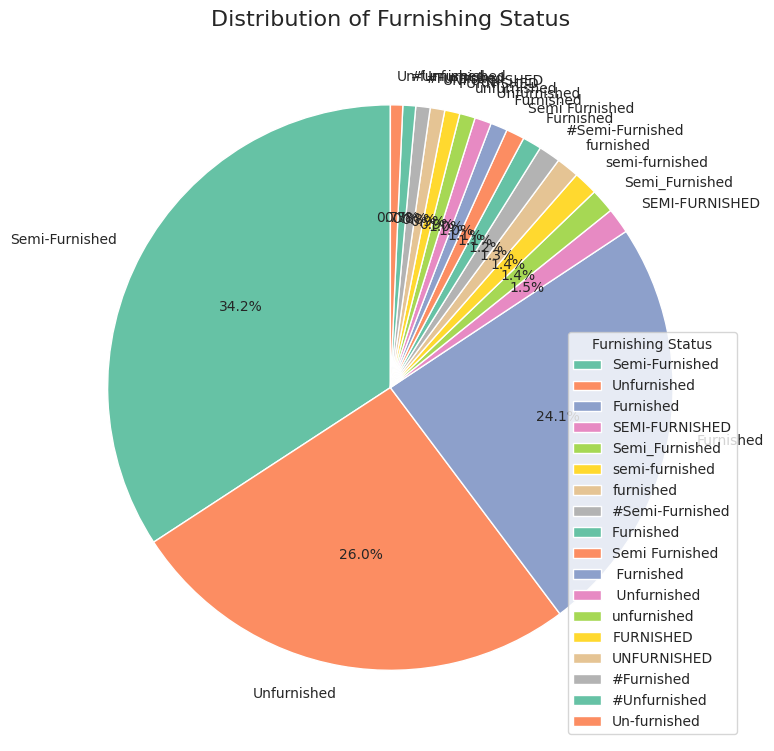

In [8]:
#piechart

furnishing_count = df['Furnishing_Status'].dropna().value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    furnishing_count,
    labels=furnishing_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('Set2')
)

plt.title('Distribution of Furnishing Status', fontsize=16)

plt.legend(
    title='Furnishing Status',
    loc='best'
)

plt.tight_layout()

plt.savefig('pie_chart.png', dpi=300, bbox_inches='tight')

plt.show()

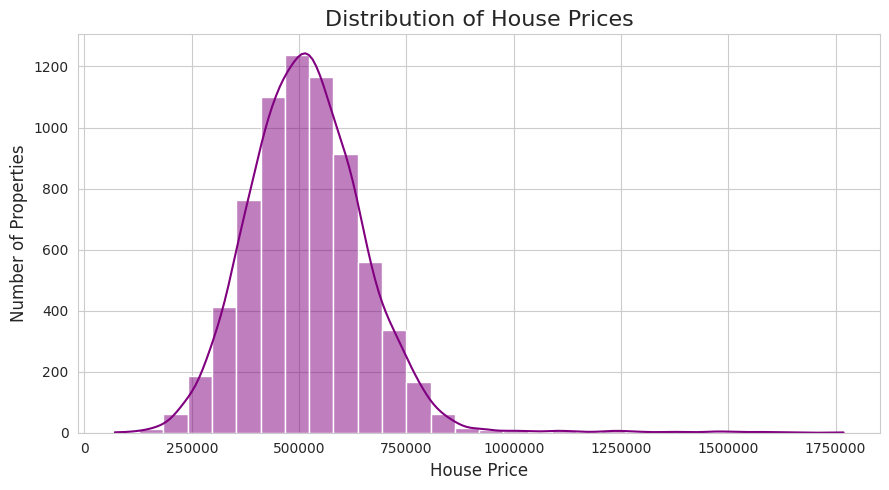

In [9]:
# histogram

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='Price',
    bins=30,
    kde=True,
    color='purple'
)

plt.title('Distribution of House Prices', fontsize=16)
plt.xlabel('House Price', fontsize=12)
plt.ylabel('Number of Properties', fontsize=12)

plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()

plt.savefig('histogram.png', dpi=300, bbox_inches='tight')

plt.show()

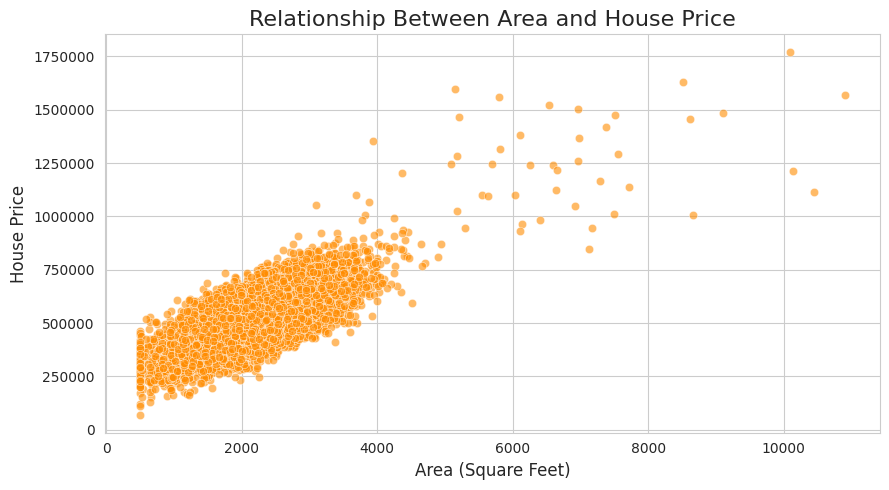

In [10]:
#scatterplot

scatter_data = df[['Area_Sqft', 'Price']].dropna()

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=scatter_data,
    x='Area_Sqft',
    y='Price',
    alpha=0.6,
    color='darkorange'
)

plt.title('Relationship Between Area and House Price', fontsize=16)
plt.xlabel('Area (Square Feet)', fontsize=12)
plt.ylabel('House Price', fontsize=12)

plt.ticklabel_format(style='plain', axis='both')

plt.tight_layout()

plt.savefig('scatter_plot.png', dpi=300, bbox_inches='tight')

plt.show()

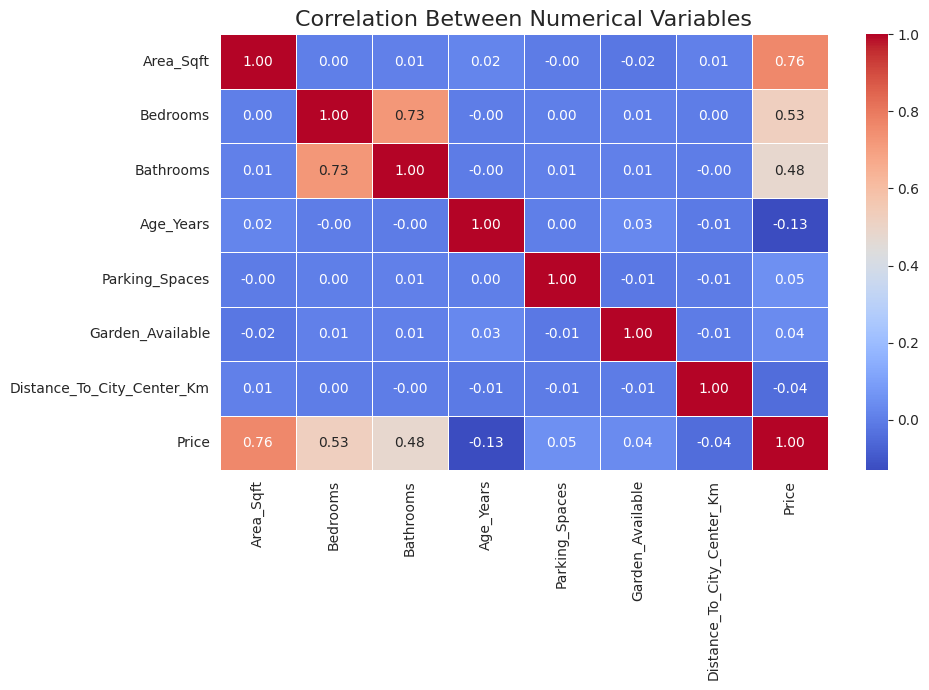

In [11]:
# corelation heatmap

numeric_columns = [
    'Area_Sqft',
    'Bedrooms',
    'Bathrooms',
    'Age_Years',
    'Parking_Spaces',
    'Garden_Available',
    'Distance_To_City_Center_Km',
    'Price'
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between Numerical Variables', fontsize=16)

plt.tight_layout()

plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')

plt.show()